# Physics for Scientists & Engineers

<img src="..//pics/cover.jpg" width=400> 


In [ ]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec

In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_Physics_4_SE_Serway_11\\ch05'

# 5 The Laws of Motion
## 5.3 Mass

$$ \frac{m_1}{m_2} \equiv \frac{a_2}{a_1} $$


## 5.4 Newton's Second Law

$$\sum \vec{F} = m \vec{a}$$

The `net force` $\sum \vec{F}$ on an object is the vector sum of all forces acting on the object.

The SI unit of force is the `newton` (N). A force of 1 N is the force that, when acting on an object of mass 1 kg, produces an acceleration of $1 m/s^2$.

$$1 N \equiv 1 kg\cdot m/s^2$$


### Example 5.1
page 113

<img src="..//pics/Fig5_4.png" width=400> 

A hockey puck having a mass of 0.30 kg slides on the frictionless,
horizontal surface of an ice rink. Two hockey sticks strike
the puck simultaneously, exerting the forces on the puck shown in
Figure 5.4. The force $\vec{F_1}$ has a magnitude of 5.0 N, and is directed
at $\theta = 20°$ below the x axis. The force $\vec{F_2}$ has a magnitude of 8.0 N,
and its direction is $\phi = 60°$ above the x axis. Determine both the
magnitude and the direction of the puck’s acceleration.

In [22]:
m = 0.30
theta = vp.radians(-20)
phi = vp.radians(60)
F_1 = vp.vec(5 * vp.cos(theta), 5 * vp.sin(theta), 0)
F_2 = vp.vec(8 * vp.cos(phi), 8 * vp.sin(phi), 0)
F_net = F_1 + F_2
a = F_net / m
print(f"Acceleration vector a = {fmt_vec(a, 1)} m/s^2")
a_mag = a.mag
print(f"Magnitud of acceleration a_mag = {a_mag:.1f} m/s^2")
alpha = vp.atan2(a.y, a.x)  # Angle of the acceleration relative to the positive x-axis
print(f"Acceleration angle alpha = {vp.degrees(alpha):.1f} degrees")


Acceleration vector a = <29.0, 17.4, 0.0> m/s^2
Magnitud of acceleration a_mag = 33.8 m/s^2
Acceleration angle alpha = 31.0 degrees


**Finalize** The vectors in Figure 5.4 can be added graphically to check the reasonableness of our answer. Because the
acceleration vector is along the direction of the resultant force, a drawing showing the resultant force vector helps us
check the validity of the answer. (Try it!)

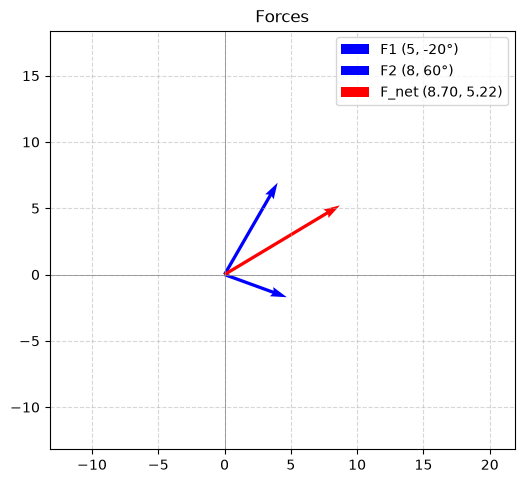

In [ ]:
from helper_functions import plot_vector, plot_vector_xy


fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

F1_mag = 5
theta_deg = -20
F2_mag = 8
phi_deg = 60

plot_vector(F1_mag, theta_deg, ax=ax, color="b", label=f"F1 ({F1_mag}, {theta_deg}°)")
plot_vector(F2_mag, phi_deg, ax=ax, color="b", label=f"F2 ({F2_mag}, {phi_deg}°)")

plot_vector_xy(
    F_net.x, F_net.y, ax=ax, color="r", label=f"F_net ({F_net.x:.2f}, {F_net.y:.2f})"
)

plt.title("Forces")
plt.show()


In [ ]:
alpha = vp.atan2(
    F_net.y, F_net.x
)  # Angle of the net force relative to the positive x-axis
print(f"Net Force angle alpha = {vp.degrees(alpha):.1f} degrees")

Net Force angle alpha = 31.0 degrees


#### What If?
Suppose three hockey sticks strike the puck simultaneously, with two of them exerting the forces shown in Figure 5.4. The
result of the three forces is that the hockey puck shows no acceleration. What must be the components of the third force?

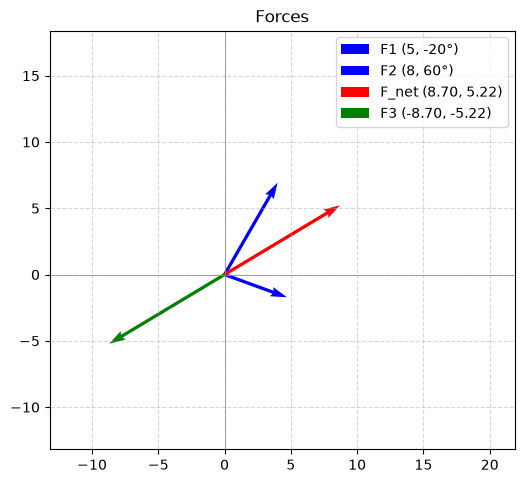

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

F1_mag = 5
theta_deg = -20
F2_mag = 8
phi_deg = 60


plot_vector(F1_mag, theta_deg, ax=ax, color="b", label=f"F1 ({F1_mag}, {theta_deg}°)")
plot_vector(F2_mag, phi_deg, ax=ax, color="b", label=f"F2 ({F2_mag}, {phi_deg}°)")

plot_vector_xy(
    F_net.x, F_net.y, ax=ax, color="r", label=f"F_net ({F_net.x:.2f}, {F_net.y:.2f})"
)
plot_vector_xy(
    -F_net.x, -F_net.y, ax=ax, color="g", label=f"F3 ({-F_net.x:.2f}, {-F_net.y:.2f})"
)


plt.title("Forces")
plt.show()

## 5.5 The Gravitational Force and Weight
$$\vec{F}_g = m \vec{g}$$

## 5.6 Newton's Tird Law

If two objects interact, the force $\vec{F}_{12}$ exerted by object 1 on object 2 is equal in magnitude
and opposite in direction to the force $\vec{F}_{21}$  exerted by object 2 on object 1:

$$\vec{F}_{12} = - \vec{F}_{21}$$

## 5.7 Analysis Models Using Newton’s Second Law
### Analysis Model: The Particle in Equilibrium

If the acceleration of an object modeled as a particle is zero, the object is treated with the
**particle in equilibrium** model. In this model, the net force on the object is zero:

$$\vec{F} = 0$$

### Example 5.6
page 122

<img src="..//pics/Fig5_13.png" width=400> 

A car of mass m is on an icy driveway inclined at
an angle $\theta$ as in Figure 5.13a.

**(A)** Find the acceleration of the car, assuming
the driveway is frictionless.

$$\sum F_x = mg \sin \theta = m a_x$$

$$\sum F_y = n - mg \cos \theta = 0$$

$$a_x = g \sin \theta$$

From the kinematic equation:
$$x_f = x_i + v_{xi} t + \frac{1}{2}a_x t^2 \implies d = \frac{1}{2}a_x t^2$$
Solve for t:
$$t = \sqrt{\frac{2d}{a_x}} = \sqrt{\frac{2d}{g sin \theta}}$$

The final velocity is from the equation:
$$v_{xf}^2 = v_{xi}^2 + 2 a_x(x_f - x_i) = 0 + 2 a_x d$$

$$v_{xf} = \sqrt{2a_x d} = \sqrt{2g d \sin \theta} $$


